# INF2005 steganography demonstration

This notebook sends one message through PNG and WAV carriers. A sender embeds and
signs it. In stage 4b, the receiver also receives start unit, LSB count, and
complete serialized record length out of band. The plaintext record prefix still
leaks the packet location; stage 4c must encrypt the record to remove that leak.

## Setup

`samples/Banana.png` is the cover image. Generated files go to a temporary
directory and are removed at the end.

In [1]:
import os
import sys
import tempfile
import wave
from datetime import datetime, timezone
from pathlib import Path

from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "stego" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from IPython.display import Audio
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont

from stego import *

_demo_temp = tempfile.TemporaryDirectory(prefix="inf2005-demo-")
DEMO_DIR = Path(_demo_temp.name)
sample_png_path = REPO_ROOT / "samples" / "Banana.png"


def preview_image(path):
    with Image.open(path) as image:
        preview = image.copy()
    preview.thumbnail((320, 392))
    return preview


def show_panels(panels, scale=1, gap=16, background="white", direction="horizontal"):
    font = ImageFont.load_default()
    prepared = []
    for image, label in panels:
        image = image.convert("RGB")
        image = image.resize((image.width * scale, image.height * scale), Image.Resampling.NEAREST)
        prepared.append((image, str(label)))
    label_height = max(font.getbbox(label)[3] - font.getbbox(label)[1] for _, label in prepared)
    panel_top = label_height + 8
    if direction == "horizontal":
        canvas_width = sum(image.width for image, _ in prepared) + gap * (len(prepared) - 1)
        canvas_height = panel_top + max(image.height for image, _ in prepared) + 2
    elif direction == "vertical":
        canvas_width = max(image.width for image, _ in prepared)
        canvas_height = sum(panel_top + image.height + 2 for image, _ in prepared) + gap * (len(prepared) - 1)
    else:
        raise ValueError("direction must be horizontal or vertical")
    canvas = Image.new("RGB", (canvas_width, canvas_height), background)
    draw = ImageDraw.Draw(canvas)
    if direction == "horizontal":
        positions = ((sum(image.width + gap for image, _ in prepared[:index]), panel_top) for index in range(len(prepared)))
    else:
        positions = ((0, panel_top + sum(panel_top + image.height + 2 + gap for image, _ in prepared[:index])) for index in range(len(prepared)))
    for (image, label), (x, y) in zip(prepared, positions):
        draw.text((x, y - panel_top + 2), label, fill="black", font=font)
        panel_y = y
        canvas.paste(image, (x, panel_y))
        draw.rectangle((x, panel_y, x + image.width - 1, panel_y + image.height - 1), outline="black", width=1)
    return canvas

def print_hexdump(data, start=0, end=None):
    end = len(data) if end is None else min(end, len(data))
    for offset in range(start, end, 16):
        chunk = data[offset:min(offset + 16, end)]
        print(f"{offset:04x}: {chunk.hex(' ')}")

print(f"Temporary demonstration files: {DEMO_DIR}")
print(f"Sample cover: {sample_png_path}")

Temporary demonstration files: /tmp/inf2005-demo-i1ijtr48
Sample cover: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png


## Sender

The sender loads a cover, chooses embedding settings, signs a message, and writes
a stego file.

### Load the cover image

The media adapter accepts this RGB PNG. The display is smaller, but encoding uses
the full array.

Input path: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png
Array shape: (1568, 1280, 3)
Array dtype: uint8


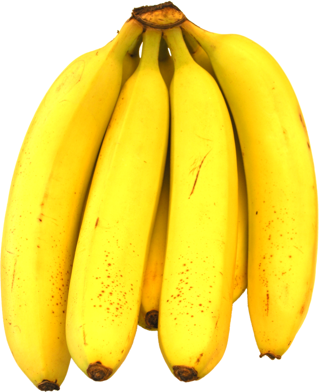

In [2]:
cover_array = load_png_from_path(sample_png_path)
cover_carrier = rgb_array_to_carrier(cover_array)
cover_image = Image.fromarray(cover_array, mode="RGB")
cover_display = cover_image.copy()
cover_display.thumbnail((320, 392))
print("Input path:", sample_png_path)
print("Array shape:", cover_array.shape)
print("Array dtype:", cover_array.dtype)
display(cover_display)

### Choose the message and embedding settings

A carrier unit is one byte used for embedding. The LSB count (`k`) is the number
of low bits used in each unit. The start unit marks where the packet begins.

The image provides 6,021,120 carrier units. The packet uses a textured banana
region rather than the white background, so the changes can be measured.

In [3]:
private_key, public_key = generate_rsa_keypair()
public_key_path = DEMO_DIR / "banana-public-key.pem"
stego_png_path = DEMO_DIR / "banana-stego.png"
save_rsa_public_key_pem(public_key, public_key_path)
start_unit = 2997120
lsb_count = 3
image_message = b"INF2005 end-to-end image demonstration"
image_metadata = b"kind=png;flow=sender-receiver"
print(f"Carrier units: {cover_array.shape[1]}*{cover_array.shape[0]}*{cover_array.shape[2]} = {cover_carrier.size}")
print(f"Capacity at k={lsb_count}: {cover_carrier.size * lsb_count} bits ({cover_carrier.size * lsb_count // 8} bytes before packet overhead)")
print("Start unit:", start_unit)
print("LSB count:", lsb_count)
print("Message bytes:", image_message)
print("Metadata:", image_metadata)
print("Public-key fingerprint:", display_rsa_public_key_fingerprint(public_key))

Carrier units: 1280*1568*3 = 6021120
Capacity at k=3: 18063360 bits (2257920 bytes before packet overhead)
Start unit: 2997120
LSB count: 3
Message bytes: b'INF2005 end-to-end image demonstration'
Metadata: b'kind=png;flow=sender-receiver'
Public-key fingerprint: SHA256:I8iQkEwtMNP/N6ilVns80Fc3paSUCISTcVumengo6I4


### Embed the message

`encode_png` writes the signed packet and returns its layout and payload.

In [4]:
png_layout, png_payload = encode_png(
    sample_png_path,
    stego_png_path,
    private_key,
    start_unit=start_unit,
    lsb_count=lsb_count,
    user_payload=image_message,
    metadata=image_metadata,
)

### Inspect the packet

Here is what the encoder produced: where the packet sits and what it contains. A
footprint is the range of carrier units used by the packet. The media hash is a
digest of the carrier with the embedded low bits masked out.

In [5]:
print("Layout.start_unit:", png_layout.start_unit)
print("Layout.lsb_count:", png_layout.lsb_count)
print("Layout.payload_length:", png_layout.payload_length)
print("Layout.footprint:", png_layout.footprint)
print("Layout.pad_bits:", png_layout.pad_bits)
print("Payload.media_id:", png_payload.media_id)
print("Payload.timestamp (integer):", png_payload.timestamp)
print("Payload.timestamp (UTC):", datetime.fromtimestamp(png_payload.timestamp, timezone.utc).isoformat())
print("Payload.nonce (hex):", png_payload.nonce.hex())
print("Payload.media_hash (hex):", png_payload.media_hash.hex())
print("Payload.user_payload:", png_payload.user_payload)
print("Payload.metadata:", png_payload.metadata)
png_payload_bytes = serialize_payload(png_payload)
print("Serialized payload hexdump (first 64 and last 16 bytes):")
print_hexdump(png_payload_bytes, 0, 64)
print(f"... [{len(png_payload_bytes) - 80} bytes skipped] ...")
print_hexdump(png_payload_bytes, len(png_payload_bytes) - 16)

Layout.start_unit: 2997120
Layout.lsb_count: 3
Layout.payload_length: 168
Layout.footprint: 1131
Layout.pad_bits: 1
Payload.media_id: IMG-c2b6c58bacff2161b2258a8f7556b029
Payload.timestamp (integer): 1789382898
Payload.timestamp (UTC): 2026-09-14T10:48:18+00:00
Payload.nonce (hex): c08c8935a8d39d082e7e8c758c212ab4
Payload.media_hash (hex): 0f8dd0ed5b5694ae340e1b6c5a233a6671cd73beabaa40fae030930bf47db474
Payload.user_payload: b'INF2005 end-to-end image demonstration'
Payload.metadata: b'kind=png;flow=sender-receiver'
Serialized payload hexdump (first 64 and last 16 bytes):
0000: 24 49 4d 47 2d 63 32 62 36 63 35 38 62 61 63 66
0010: 66 32 31 36 31 62 32 32 35 38 61 38 66 37 35 35
0020: 36 62 30 32 39 00 00 00 00 6a a7 d0 f2 c0 8c 89
0030: 35 a8 d3 9d 08 2e 7e 8c 75 8c 21 2a b4 0f 8d d0
... [88 bytes skipped] ...
0098: 3d 73 65 6e 64 65 72 2d 72 65 63 65 69 76 65 72


### What the signature covers

The signed bytes begin with the ASCII domain tag `INF2005-ACW1\0SIGN\0`. They
then contain the protocol version, LSB count, media code, total units, start unit,
footprint, payload length, media context, and payload. Because the geometry is
signed, moving the packet invalidates the signature even when its payload is
unchanged.

In [6]:
# RE-DERIVED FOR DISPLAY ONLY; encode_png produced the signature internally.
# encode_png does not return its media context, so this adapter call is unavoidable.
png_signed_input = encode_signing_input(
    IMAGE_MEDIA_CODE,
    encode_png_media_context(cover_array.shape, cover_carrier.size),
    png_layout,
    png_payload_bytes,
)
print("Signed-input length:", len(png_signed_input))
print("Signed-input hexdump (first 96 bytes):")
print_hexdump(png_signed_input, 0, 96)

Signed-input length: 210
Signed-input hexdump (first 96 bytes):
0000: 49 4e 46 32 30 30 35 2d 41 43 57 31 00 53 49 47
0010: 4e 00 01 00 01 03 5b e0 00 2d bb 80 00 04 6b 00
0020: 00 a8 00 00 05 00 00 00 06 20 24 49 4d 47 2d 63
0030: 32 62 36 63 35 38 62 61 63 66 66 32 31 36 31 62
0040: 32 32 35 38 61 38 66 37 35 35 36 62 30 32 39 00
0050: 00 00 00 6a a7 d0 f2 c0 8c 89 35 a8 d3 9d 08 2e


### Inspect the written image

At normal scale, the cover and stego image look the same. The table compares real
carrier units before and after embedding. With `k=3`, only the low three bits may
differ. The packet uses about 397 pixels out of 2,007,040. The red strip and
stacked panels use one window centred on the first packet pixel. The strip contains
the full packet with a small margin. The packet caption describes the full packet;
the window caption describes the zoom. The mask is black at both margins, then a
white line runs across the centre row for nearly the full strip width.

Stego path: /tmp/inf2005-demo-i1ijtr48/banana-stego.png
Stego file bytes: 1674495
Differing pixel values: 977
Cover values across packet footprint: min= 0 max= 255
First 8 carrier units at packet location:
index | cover decimal | cover binary | stego decimal | stego binary
    0 |            130 | 10000010 |            129 | 10000001
    1 |             85 | 01010101 |             81 | 01010001
    2 |              0 | 00000000 |              0 | 00000000
    3 |            118 | 01110110 |            116 | 01110100
    4 |             74 | 01001010 |             76 | 01001100
    5 |              0 | 00000000 |              5 | 00000101
    6 |            115 | 01110011 |            113 | 01110001
    7 |             74 | 01001010 |             77 | 01001101
Packet region: 377 pixels of 2,007,040 (0.02% of the image)
Packet span: row 780, columns 640 to 1016
Zoom window: 401×27 pixels, rows 767 to 793, columns 628 to 1028; full packet with margins


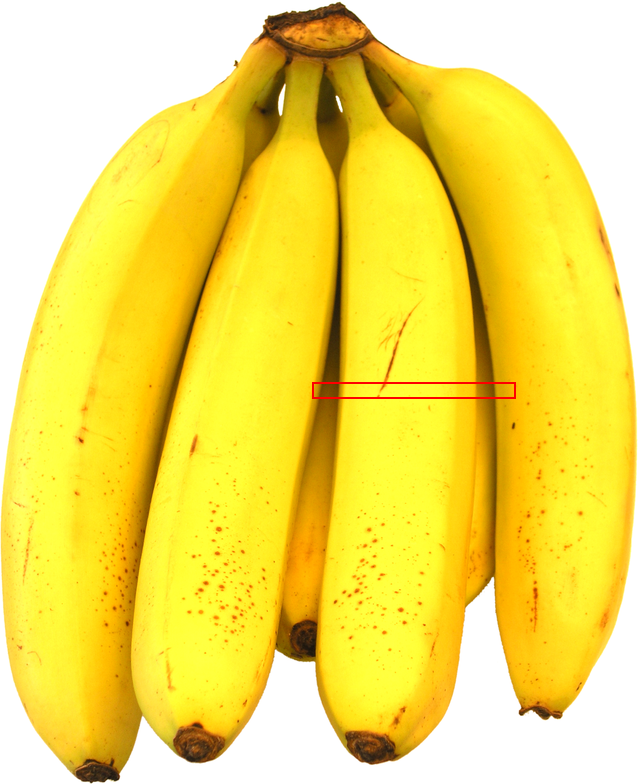

In [7]:
stego_array = load_png_from_path(stego_png_path)
stego_image = Image.fromarray(stego_array, mode="RGB")
stego_carrier = rgb_array_to_carrier(stego_array)
packet_cover_units = cover_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint]
packet_stego_units = stego_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint]
print("Stego path:", stego_png_path)
print("Stego file bytes:", stego_png_path.stat().st_size)
print("Differing pixel values:", int(np.count_nonzero(stego_array != cover_array)))
print("Cover values across packet footprint: min=", int(packet_cover_units.min()), "max=", int(packet_cover_units.max()))
print("First 8 carrier units at packet location:")
print("index | cover decimal | cover binary | stego decimal | stego binary")
for offset, (cover_value, stego_value) in enumerate(zip(packet_cover_units[:8], packet_stego_units[:8])):
    print(f"{offset:5d} | {int(cover_value):14d} | {int(cover_value):08b} | {int(stego_value):14d} | {int(stego_value):08b}")

packet_start_pixel = png_layout.start_unit // cover_array.shape[2]
packet_pixel_count = png_layout.footprint // cover_array.shape[2]
packet_end_pixel = packet_start_pixel + packet_pixel_count - 1
packet_start_y, packet_start_x = divmod(packet_start_pixel, cover_array.shape[1])
packet_end_y, packet_end_x = divmod(packet_end_pixel, cover_array.shape[1])
total_pixel_count = cover_array.shape[0] * cover_array.shape[1]
horizontal_margin = 12
vertical_margin = 13
window_box = (
    packet_start_x - horizontal_margin,
    packet_start_y - vertical_margin,
    packet_end_x + horizontal_margin + 1,
    packet_end_y + vertical_margin + 1,
)
window_width = window_box[2] - window_box[0]
window_height = window_box[3] - window_box[1]
whole_image = cover_image.copy()
whole_display = whole_image.resize((640, 784), Image.Resampling.LANCZOS)
display_scale_x = whole_display.width / whole_image.width
display_scale_y = whole_display.height / whole_image.height
display_window_box = (
    round(window_box[0] * display_scale_x) - 2,
    round(window_box[1] * display_scale_y) - 2,
    round(window_box[2] * display_scale_x) + 1,
    round(window_box[3] * display_scale_y) + 1,
)
ImageDraw.Draw(whole_display).rectangle(display_window_box, outline="red", width=2)
print(f"Packet region: {packet_pixel_count:,} pixels of {total_pixel_count:,} ({packet_pixel_count / total_pixel_count:.2%} of the image)")
print(f"Packet span: row {packet_start_y}, columns {packet_start_x} to {packet_end_x}")
print(f"Zoom window: {window_width}×{window_height} pixels, rows {window_box[1]} to {window_box[3] - 1}, columns {window_box[0]} to {window_box[2] - 1}; full packet with margins")
display(whole_display)

### Inspect the packet window

The zoomed panels show the cover, stego image, and changed carrier units.

Full packet strip, stacked at 2x: cover, stego, changed units:


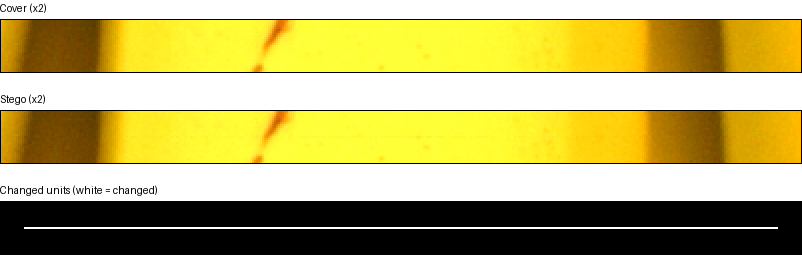

In [8]:
print("Full packet strip, stacked at 2x: cover, stego, changed units:")
cover_crop = cover_image.crop(window_box)
stego_crop = stego_image.crop(window_box)
changed_carrier = stego_carrier != cover_carrier
changed_pixel_mask = np.any(changed_carrier.reshape(cover_array.shape), axis=2)
changed_mask_image = Image.fromarray(np.where(changed_pixel_mask, 255, 0).astype(np.uint8), mode="L")
changed_crop = changed_mask_image.crop(window_box)
display(show_panels([(cover_crop, "Cover (x2)"), (stego_crop, "Stego (x2)"), (changed_crop, "Changed units (white = changed)")], scale=2, direction="vertical"))

### End the sender phase

The receiver gets no signing key. The sender passes the packet geometry as
out-of-band values before the sender-only signing state is removed.

In [9]:
# Sender-only state is deliberately discarded before the receiver acts.
receiver_start_unit = png_layout.start_unit
receiver_lsb_count = png_layout.lsb_count
receiver_payload_length = png_layout.payload_length
del private_key
del public_key, png_layout, png_payload, png_payload_bytes, png_signed_input
del cover_array, cover_carrier, cover_image, cover_display, stego_array, stego_image, stego_carrier
del packet_cover_units, packet_stego_units, whole_image, whole_display, display_window_box, cover_crop, stego_crop, changed_carrier, changed_pixel_mask, changed_mask_image, changed_crop
del packet_start_pixel, packet_end_pixel, packet_start_y, packet_start_x, packet_end_y, packet_end_x, packet_pixel_count, total_pixel_count, horizontal_margin, vertical_margin, window_box, window_width, window_height, display_scale_x, display_scale_y
del start_unit, lsb_count, image_message, image_metadata

## Receiver

The receiver receives the geometry, loads the public key, and verifies the file.

### Files available to the receiver

The receiver has the stego image path, public-key PEM path, and geometry received
out of band: the start unit, LSB count, and complete serialized record length.

In [10]:
print("Stego file path:", stego_png_path)
print("Public-key PEM path:", public_key_path)

Stego file path: /tmp/inf2005-demo-i1ijtr48/banana-stego.png
Public-key PEM path: /tmp/inf2005-demo-i1ijtr48/banana-public-key.pem


### Receive the packet geometry

Stage 4b has no public marker or scanner. The sender supplies the start unit, LSB
count, and complete serialized record length through a separate channel.

In [11]:
receiver_geometry = {"start_unit": receiver_start_unit, "lsb_count": receiver_lsb_count, "payload_length": receiver_payload_length}
print("Out-of-band geometry:", receiver_geometry)

Out-of-band geometry: {'start_unit': 2997120, 'lsb_count': 3, 'payload_length': 168}


### Verify the payload

The receiver loads the public key and verifies the stego image. A valid result
returns the media ID, timestamp, and message.

In [12]:
receiver_public_key = load_rsa_public_key_pem(public_key_path)
png_result = verify_png(stego_png_path, receiver_public_key, receiver_start_unit, receiver_lsb_count, receiver_payload_length)
print("PNG verdict:", png_result.verdict)
print("Key fingerprint:", png_result.key_fingerprint)
print("Media ID:", png_result.payload.media_id)
print("Timestamp:", png_result.payload.timestamp)
print("Recovered message:", png_result.payload.user_payload.decode("utf-8"))

PNG verdict: Authentic
Key fingerprint: SHA256:I8iQkEwtMNP/N6ilVns80Fc3paSUCISTcVumengo6I4
Media ID: IMG-c2b6c58bacff2161b2258a8f7556b029
Timestamp: 1789382898
Recovered message: INF2005 end-to-end image demonstration


## Failure cases

Change the image or public key and compare the verdict. The untouched cover has no
packet.

### Altered image

Change one carrier unit outside the packet. The signature still verifies, but the
masked media hash reports tampering.

In [13]:
altered_png_path = DEMO_DIR / "banana-altered.png"
altered_image = load_png_from_path(stego_png_path)
altered_carrier = rgb_array_to_carrier(altered_image)
altered_carrier[-1] ^= np.uint8(1)
save_rgb_png_to_path(carrier_to_rgb_array(altered_carrier, altered_image.shape), altered_png_path)
print("Altered PNG verdict:", verify_png(altered_png_path, receiver_public_key, receiver_start_unit, receiver_lsb_count, receiver_payload_length).verdict)

Altered PNG verdict: Tampered


### Wrong public key

A signature made by the sender cannot be verified with an unrelated public key.

In [14]:
wrong_private_key, wrong_public_key = generate_rsa_keypair()
del wrong_private_key
print("Wrong-key PNG verdict:", verify_png(stego_png_path, wrong_public_key, receiver_start_unit, receiver_lsb_count, receiver_payload_length).verdict)

Wrong-key PNG verdict: Signature Invalid


### Untouched cover

The original cover does not contain a valid packet at the supplied geometry.

In [15]:
print("Untouched cover verdict:", verify_png(sample_png_path, receiver_public_key, receiver_start_unit, receiver_lsb_count, receiver_payload_length).verdict)
del wrong_public_key, altered_image, altered_carrier

Untouched cover verdict: Cannot Verify


### Does the raw payload fit?

The raw RGB data is 1280 × 1568 × 3 = 6,021,120 bytes, exactly one byte per
carrier unit. At `k=8`, the carrier can hold one byte per unit, but the packet also
needs its signature and payload-record framing. The PNG file is only 1,673,875
bytes because PNG compresses; using that file would make the k=3 case fit and would
answer a different question.

In [16]:
capacity_cover_array = load_png_from_path(sample_png_path)
capacity_carrier = rgb_array_to_carrier(capacity_cover_array)
capacity_payload = capacity_cover_array.tobytes()
capacity_metadata = b"capacity test"
capacity_at_k8 = capacity_carrier.size * 8 // 8
capacity_private_key, capacity_unused_public_key = generate_rsa_keypair()
try:
    encode_png(
        sample_png_path,
        DEMO_DIR / "capacity-k8.png",
        capacity_private_key,
        start_unit=0,
        lsb_count=8,
        user_payload=capacity_payload,
        metadata=capacity_metadata,
    )
    capacity_result = "Unexpected result: the capacity case was accepted"
except ValueError as error:
    capacity_result = f"Capacity refusal: {error}"
print(f"Raw RGB payload: {len(capacity_payload):,} bytes")
print(f"Carrier capacity at k=8: {capacity_carrier.size:,} carrier units × 8 bits ÷ 8 = {capacity_at_k8:,} bytes")
print(capacity_result)
del capacity_cover_array, capacity_carrier, capacity_payload, capacity_metadata, capacity_at_k8
del capacity_private_key, capacity_unused_public_key

Raw RGB payload: 6,021,120 bytes
Carrier capacity at k=8: 6,021,120 carrier units × 8 bits ÷ 8 = 6,021,120 bytes
Capacity refusal: embedding footprint does not fit after start_unit: total_units=6021120, start_unit=0, lsb_count=8, max_record_length=6020864


## WAV example

The same sender/receiver flow works for a mono 8-bit PCM sine tone. The final
alteration shows tamper detection.

In [17]:
wav_cover_path = DEMO_DIR / "tone-cover.wav"
wav_stego_path = DEMO_DIR / "tone-stego.wav"
wav_public_key_path = DEMO_DIR / "tone-public-key.pem"
wav_altered_path = DEMO_DIR / "tone-altered.wav"
wav_samples = (128 + 90 * np.sin(2 * np.pi * 440 * np.arange(32000) / 8000)).astype(np.uint8).tobytes()
with wave.open(str(wav_cover_path), "wb") as wav_file:
    wav_file.setnchannels(1)
    wav_file.setsampwidth(1)
    wav_file.setframerate(8000)
    wav_file.writeframes(wav_samples)

wav_private_key, wav_public_key = generate_rsa_keypair()
wav_start_unit = 61
wav_lsb_count = 5
wav_layout, _ = encode_wav(
    wav_cover_path,
    wav_stego_path,
    wav_private_key,
    start_unit=wav_start_unit,
    lsb_count=wav_lsb_count,
    user_payload=b"INF2005 end-to-end audio demonstration",
    metadata=b"kind=wav;flow=sender-receiver",
)
save_rsa_public_key_pem(wav_public_key, wav_public_key_path)

# Keep the WAV receiver step independent of the sender's key too.
wav_geometry = (wav_layout.start_unit, wav_layout.lsb_count, wav_layout.payload_length)
del wav_private_key, wav_public_key, wav_layout, wav_samples
del wav_start_unit, wav_lsb_count
wav_receiver_key = load_rsa_public_key_pem(wav_public_key_path)
wav_result = verify_wav(wav_stego_path, wav_receiver_key, *wav_geometry)
print("WAV verdict:", wav_result.verdict)
print("Key fingerprint:", wav_result.key_fingerprint)
print("WAV recovered message:", wav_result.payload.user_payload.decode("utf-8"))

wav_data = load_pcm_wav_from_path(wav_stego_path)
wav_carrier = wav_frame_bytes_to_carrier(wav_data.frame_bytes, wav_data.sample_width)
wav_carrier[-1] ^= np.uint8(1)
save_pcm_wav_to_path(wav_data_with_carrier(wav_data, wav_carrier), wav_altered_path)
print("Altered WAV verdict:", verify_wav(wav_altered_path, wav_receiver_key, *wav_geometry).verdict)
del wav_data, wav_carrier

WAV verdict: Authentic
Key fingerprint: SHA256:ndZdfr9i0U3WXb1Mr5xHUZA9e/h2TFYrAxkva/OWisY
WAV recovered message: INF2005 end-to-end audio demonstration
Altered WAV verdict: Tampered


## Analysis: compare `k=1` and `k=8`

A larger `k` uses more low bits per carrier unit and needs fewer units for the
packet. Compare the footprint and visual effect.

{'k': 1, 'capacity_bits': 6021120, 'packet_bits': 3192, 'footprint': 3192, 'changed_values': 1637, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
{'k': 8, 'capacity_bits': 48168960, 'packet_bits': 3192, 'footprint': 399, 'changed_values': 398, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
Cover, k=1, and k=8, labelled and downscaled for display:


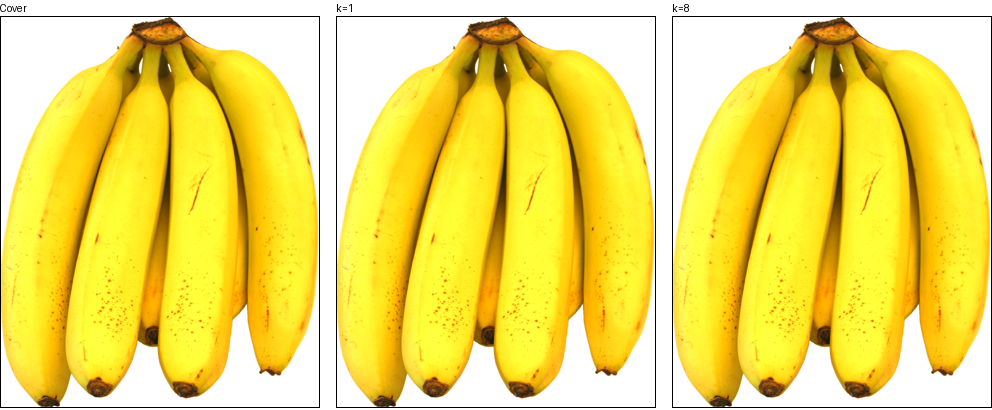

In [18]:
analysis_private_key, analysis_public_key = generate_rsa_keypair()
analysis_rows = []
analysis_previews = []
analysis_cover_array = load_png_from_path(sample_png_path)
analysis_cover_image = Image.fromarray(analysis_cover_array, mode="RGB")
for analysis_k in (1, 8):
    analysis_output = DEMO_DIR / f"banana-analysis-k{analysis_k}.png"
    analysis_layout, _ = encode_png(
        sample_png_path,
        analysis_output,
        analysis_private_key,
        start_unit=0,
        lsb_count=analysis_k,
        user_payload=b"same analysis payload",
        metadata=b"analysis=k comparison",
    )
    analysis_result = verify_png(analysis_output, analysis_public_key, analysis_layout.start_unit, analysis_layout.lsb_count, analysis_layout.payload_length)
    analysis_image = np.asarray(Image.open(analysis_output), dtype=np.uint8)
    changed_values = int(np.count_nonzero(analysis_image != analysis_cover_array))
    preserved = preserved_bit_count(analysis_layout.total_units, analysis_layout.footprint, analysis_layout.lsb_count, 0)
    packet_bits = (analysis_layout.payload_length + RSA_SIGNATURE_SIZE) * 8
    analysis_rows.append({
        "k": analysis_k,
        "capacity_bits": analysis_layout.total_units * analysis_k,
        "packet_bits": packet_bits,
        "footprint": analysis_layout.footprint,
        "changed_values": changed_values,
        "preserved_ratio": f"{preserved / (analysis_layout.total_units * 8):.2%}",
        "verdict": analysis_result.verdict,
    })
    analysis_preview = Image.fromarray(analysis_image, mode="RGB")
    analysis_preview.thumbnail((320, 392))
    analysis_previews.append((analysis_preview, f"k={analysis_k}"))
for row in analysis_rows:
    print(row)
analysis_cover_preview = analysis_cover_image.copy()
analysis_cover_preview.thumbnail((320, 392))
print("Cover, k=1, and k=8, labelled and downscaled for display:")
display(show_panels([(analysis_cover_preview, "Cover"), *analysis_previews], scale=1))
del analysis_private_key, analysis_public_key, analysis_cover_array, analysis_cover_image, analysis_rows, analysis_previews, analysis_cover_preview

## Confidentiality payload

The packet location is public in this design, so confidentiality comes from encrypting the payload, not from hiding where it sits. Alice signs the encrypted bytes, and Bob decrypts them with his private key.

In [19]:
def oaep_sha256() -> padding.OAEP:
    return padding.OAEP(
        mgf=padding.MGF1(algorithm=hashes.SHA256()),
        algorithm=hashes.SHA256(),
        label=None,
    )


def seal(plaintext: bytes, bob_public_key: rsa.RSAPublicKey) -> bytes:
    aes_key = AESGCM.generate_key(bit_length=256)
    nonce = os.urandom(12)
    ciphertext_with_tag = AESGCM(aes_key).encrypt(nonce, plaintext, None)
    wrapped_key = bob_public_key.encrypt(aes_key, oaep_sha256())
    return wrapped_key + nonce + ciphertext_with_tag


def unseal(sealed_blob: bytes, bob_private_key: rsa.RSAPrivateKey) -> bytes:
    wrapped_key_size = 256
    nonce_size = 12
    tag_size = 16
    prefix_size = wrapped_key_size + nonce_size
    if len(sealed_blob) < prefix_size + tag_size:
        raise ValueError("sealed payload is too short")
    wrapped_key = sealed_blob[:wrapped_key_size]
    nonce = sealed_blob[wrapped_key_size:prefix_size]
    ciphertext_with_tag = sealed_blob[prefix_size:]
    aes_key = bob_private_key.decrypt(wrapped_key, oaep_sha256())
    return AESGCM(aes_key).decrypt(nonce, ciphertext_with_tag, None)


alice_private_key, alice_public_key = generate_rsa_keypair()
bob_private_key, bob_public_key = generate_rsa_keypair()
alice_public_key_path = DEMO_DIR / "confidential-alice-public-key.pem"
bob_public_key_path = DEMO_DIR / "confidential-bob-public-key.pem"
bob_private_key_path = DEMO_DIR / "confidential-bob-private-key.pem"
bob_private_key_password = b"bob-demo-password"
save_rsa_public_key_pem(alice_public_key, alice_public_key_path)
save_rsa_public_key_pem(bob_public_key, bob_public_key_path)
save_rsa_private_key_pem(bob_private_key, bob_private_key_path, password=bob_private_key_password)
alice_bob_public_key = load_rsa_public_key_pem(bob_public_key_path)
del bob_public_key, bob_private_key

print("Alice public-key fingerprint:", display_rsa_public_key_fingerprint(alice_public_key))
print("Bob public-key fingerprint:", display_rsa_public_key_fingerprint(alice_bob_public_key))
print("Bob publishes his public key; Alice checks the fingerprint out of band.")

confidential_plaintext = b"INF2005 confidential message for Bob"
confidential_blob = seal(confidential_plaintext, alice_bob_public_key)
wrapped_key_size = 256
nonce_size = 12
sealed_prefix_size = wrapped_key_size + nonce_size
print("Plaintext length:", len(confidential_plaintext))
print("Sealed blob length:", len(confidential_blob))
print(f"Blob breakdown: {wrapped_key_size} bytes wrapped key + {nonce_size} bytes nonce + {len(confidential_blob) - sealed_prefix_size} bytes ciphertext-with-tag (fixed {sealed_prefix_size}-byte prefix)")

confidential_stego_path = DEMO_DIR / "banana-confidential.png"
confidential_layout, confidential_payload = encode_png(
    sample_png_path,
    confidential_stego_path,
    alice_private_key,
    start_unit=0,
    lsb_count=3,
    user_payload=confidential_blob,
    metadata=b"kind=png;flow=confidential",
)
alice_receiver_public_key = load_rsa_public_key_pem(alice_public_key_path)
del alice_public_key
confidential_result = verify_png(confidential_stego_path, alice_receiver_public_key, confidential_layout.start_unit, confidential_layout.lsb_count, confidential_layout.payload_length)
print("Confidential PNG verdict:", confidential_result.verdict)
print("Recovered payload first 24 bytes (hex):", confidential_result.payload.user_payload[:24].hex())

bob_private_key = load_rsa_private_key_pem(bob_private_key_path, password=bob_private_key_password)
decrypted_bytes = unseal(confidential_result.payload.user_payload, bob_private_key)
print("Decrypted bytes equal original:", decrypted_bytes == confidential_plaintext)

try:
    unseal(confidential_result.payload.user_payload, alice_private_key)
except ValueError as error:
    print("Alice's private key cannot read the sealed payload:", type(error).__name__)

Alice public-key fingerprint: SHA256:q5hdTh8DwEHz0mRxaydbFRo6rv87/ObTmDXOO0DRCYE
Bob public-key fingerprint: SHA256:Ud7R93roQILWXeAFMVYJys0cGukinswEtbQQduMo/tE
Bob publishes his public key; Alice checks the fingerprint out of band.
Plaintext length: 36
Sealed blob length: 320
Blob breakdown: 256 bytes wrapped key + 12 bytes nonce + 52 bytes ciphertext-with-tag (fixed 268-byte prefix)


Confidential PNG verdict: Authentic
Recovered payload first 24 bytes (hex): 0cde6cdea600d07c15c4e9efeb452d7c774b9576ae098cd1
Decrypted bytes equal original: True
Alice's private key cannot read the sealed payload: ValueError


The following are **not encrypted**: `metadata`, `media_id`, `timestamp`, `nonce`, and `media_hash` stay readable. Anything sensitive belongs in `user_payload`.

## Typed encrypted payloads

This section continues from the confidentiality section. It reuses `seal`, `unseal`, `alice_private_key`, `alice_bob_public_key`, `bob_private_key`, and `alice_public_key_path`; it does not create another key pair. The content header is inside the sealed plaintext, never in `metadata`.

P1: declared mime=text/plain, sniffed mime=None, agree=True, name=note.txt, body length=43, verdict=Authentic
The typed payload reached the text handler.


P2: declared mime=image/png, sniffed mime=image/png, agree=True, name=generated.png, body length=196, verdict=Authentic


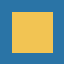

P3: declared mime=audio/wav, sniffed mime=audio/wav, agree=True, name=short-tone.wav, body length=4044, verdict=Authentic


N1: declared mime=image/png, sniffed mime=application/pdf, agree=False, name=not-really.png, body length=19, verdict=Authentic
Payload type mismatch; saved payload: /tmp/inf2005-demo-i1ijtr48/handled-not-really.png
Reason: declared MIME 'image/png' does not match sniffed MIME 'application/pdf'


N2: sender declared mime=text/plain, sniffed mime=None, agree=True, sender name=../../etc/passwd, body length=19, verdict=Authentic
N2 rejected: ValueError name must be a safe bare filename


In [20]:
def pack_content(mime: str, name: str, body: bytes) -> bytes:
    try:
        mime_bytes = mime.encode("ascii")
    except UnicodeEncodeError as error:
        raise ValueError("mime must be lowercase ASCII") from error
    if mime != mime.lower():
        raise ValueError("mime must be lowercase ASCII")
    name_bytes = name.encode("utf-8")
    if len(mime_bytes) > 255 or len(name_bytes) > 255:
        raise ValueError("mime and name must fit in one-byte lengths")
    return bytes((1, len(mime_bytes))) + mime_bytes + bytes((len(name_bytes),)) + name_bytes + body


def unpack_content(data: bytes) -> tuple[int, str, str, bytes]:
    if len(data) < 2:
        raise ValueError("content header is truncated")
    version = data[0]
    if version != 1:
        raise ValueError("unsupported content header version")
    mime_len = data[1]
    mime_start = 2
    mime_end = mime_start + mime_len
    if len(data) < mime_end + 1:
        raise ValueError("content header is shorter than its declared MIME field")
    try:
        mime = data[mime_start:mime_end].decode("ascii")
    except UnicodeDecodeError as error:
        raise ValueError("MIME must be lowercase ASCII") from error
    if mime != mime.lower():
        raise ValueError("MIME must be lowercase ASCII")
    name_len = data[mime_end]
    name_start = mime_end + 1
    name_end = name_start + name_len
    if len(data) < name_end:
        raise ValueError("content header is shorter than its declared name field")
    try:
        name = data[name_start:name_end].decode("utf-8")
    except UnicodeDecodeError as error:
        raise ValueError("name must be valid UTF-8") from error
    if any(part in name for part in ("/", "\\", "..")):
        raise ValueError("name must be a safe bare filename")
    if not mime:
        mime = "application/octet-stream"
    return version, mime, name, data[name_end:]


def sniff_mime(body: bytes) -> str | None:
    if body.startswith(b"\x89PNG"):
        return "image/png"
    if body.startswith(b"\xff\xd8\xff"):
        return "image/jpeg"
    if len(body) >= 12 and body[:4] == b"RIFF" and body[8:12] == b"WAVE":
        return "audio/wav"
    if body.startswith(b"%PDF"):
        return "application/pdf"
    return None


SNIFFABLE_MIMES = {"image/png", "image/jpeg", "audio/wav", "application/pdf"}


def mime_agrees(declared: str, body: bytes) -> bool:
    sniffed = sniff_mime(body)
    if sniffed is None:
        return declared not in SNIFFABLE_MIMES
    return sniffed == declared


def handle_payload(mime: str, name: str, body: bytes) -> None:
    safe_name = name.replace("/", "").replace("\\", "").replace("..", "")
    if safe_name in {"", "."}:
        safe_name = "payload.bin"
    output_path = DEMO_DIR / f"handled-{safe_name}"
    if not mime_agrees(mime, body):
        output_path.write_bytes(body)
        print("Payload type mismatch; saved payload:", output_path)
        print(f"Reason: declared MIME {mime!r} does not match sniffed MIME {sniff_mime(body)!r}")
        return
    if mime == "text/plain":
        try:
            print(body.decode("utf-8"))
        except UnicodeDecodeError as error:
            output_path.write_bytes(body)
            print("Invalid text payload; saved payload:", output_path)
            print("Reason:", type(error).__name__, str(error))
        return
    output_path.write_bytes(body)
    if mime in {"image/png", "image/jpeg"}:
        display(preview_image(output_path))
    elif mime in {"audio/wav", "audio/mpeg"}:
        display(Audio(filename=str(output_path)))
    else:
        print("Saved payload:", output_path)


content_receiver_public_key = load_rsa_public_key_pem(alice_public_key_path)

content_image_path = DEMO_DIR / "generated-content.png"
content_image = Image.new("RGB", (64, 64), (42, 116, 166))
content_image_draw = ImageDraw.Draw(content_image)
content_image_draw.rectangle((12, 12, 52, 52), fill=(242, 196, 83))
content_image.save(content_image_path, format="PNG")
content_image_body = content_image_path.read_bytes()

content_audio_samples = (
    128 + 80 * np.sin(2 * np.pi * 440 * np.arange(4000) / 8000)
).astype(np.uint8).tobytes()
content_audio_path = DEMO_DIR / "generated-content.wav"
with wave.open(str(content_audio_path), "wb") as content_audio_file:
    content_audio_file.setnchannels(1)
    content_audio_file.setsampwidth(1)
    content_audio_file.setframerate(8000)
    content_audio_file.writeframes(content_audio_samples)
# Replace this variable with bytes from a supplied WAV file later.
content_audio_body = content_audio_path.read_bytes()

def run_typed_case(
    label: str,
    declared_mime: str,
    name: str,
    body: bytes,
    stego_name: str,
) -> None:
    content_plaintext = pack_content(declared_mime, name, body)
    content_blob = seal(content_plaintext, alice_bob_public_key)
    stego_path = DEMO_DIR / stego_name
    layout, _ = encode_png(
        sample_png_path,
        stego_path,
        alice_private_key,
        start_unit=0,
        lsb_count=1,
        user_payload=content_blob,
        metadata=b"kind=png;flow=typed-content",
    )
    result = verify_png(stego_path, content_receiver_public_key, layout.start_unit, layout.lsb_count, layout.payload_length)
    recovered_plaintext = unseal(result.payload.user_payload, bob_private_key)
    try:
        version, recovered_mime, recovered_name, recovered_body = unpack_content(recovered_plaintext)
    except ValueError as error:
        sniffed = sniff_mime(body)
        agrees = mime_agrees(declared_mime, body)
        print(
            f"{label}: sender declared mime={declared_mime}, sniffed mime={sniffed}, "
            f"agree={agrees}, sender name={name}, body length={len(body)}, "
            f"verdict={result.verdict}"
        )
        print(f"{label} rejected: {type(error).__name__} {error}")
        return
    sniffed = sniff_mime(recovered_body)
    agrees = mime_agrees(recovered_mime, recovered_body)
    print(
        f"{label}: declared mime={recovered_mime}, sniffed mime={sniffed}, "
        f"agree={agrees}, name={recovered_name}, body length={len(recovered_body)}, "
        f"verdict={result.verdict}"
    )
    handle_payload(recovered_mime, recovered_name, recovered_body)


run_typed_case(
    "P1",
    "text/plain",
    "note.txt",
    b"The typed payload reached the text handler.",
    "typed-text.png",
)
run_typed_case("P2", "image/png", "generated.png", content_image_body, "typed-image.png")
run_typed_case("P3", "audio/wav", "short-tone.wav", content_audio_body, "typed-audio.png")
run_typed_case(
    "N1",
    "image/png",
    "not-really.png",
    b"%PDF-1.7\nnot a PNG\n",
    "typed-negative-pdf.png",
)
run_typed_case(
    "N2",
    "text/plain",
    "../../etc/passwd",
    b"name rejection test",
    "typed-negative-name.png",
)


The content header sits inside the encrypted plaintext, so an observer who locates the packet learns nothing about the file type. A signed content type is a claim by the sender, not a fact about the bytes; software that renders the payload validates it first. With a 32,000-unit WAV carrier at start unit 0 and k=1, plus empty metadata, stage 4b leaves 3,359 bytes for sealed plaintext, including its content header.

## Clean up

Generated files live in the temporary directory and are removed now.

In [21]:
_demo_temp.cleanup()
print("Temporary demonstration files removed.")

Temporary demonstration files removed.
